# Ejercicio 8.4 - Patrón estacional

Explora si hay diferencias entre la época seca (noviembre-abril) y la
lluviosa (mayo-octubre) en Guatemala, usando las 11 fechas oficiales de
cada lago. **Esto es exploratorio y descriptivo, no un modelo de
estacionalidad**: 11 fechas irregulares a lo largo de año y medio no son
una serie mensual completa.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src.comparacion_lagos import build_seasonal_summary, write_seasonal_summary
from src.config import LAGOS

resumen = build_seasonal_summary()
write_seasonal_summary(resumen)
df = pd.DataFrame(resumen)
display(df)


,lago,estacion,n_fechas,cyano_promedio,cyano_mediana,cyano_std,fechas
0,amatitlan,seca,10,5.7709,5.7475,1.6811,2025-01-28;2025-04-15;2025-04-28;2025-11-24;20...
1,amatitlan,lluviosa,1,11.4872,11.4872,0.0000,2026-06-19
2,atitlan,seca,8,1.1444,1.2649,0.6755,2025-01-18;2025-04-13;2025-11-21;2025-12-29;20...
3,atitlan,lluviosa,3,1.1775,1.1416,0.0859,2025-05-13;2025-07-17;2026-07-22


## Gráfica: promedio de cianobacteria por estación

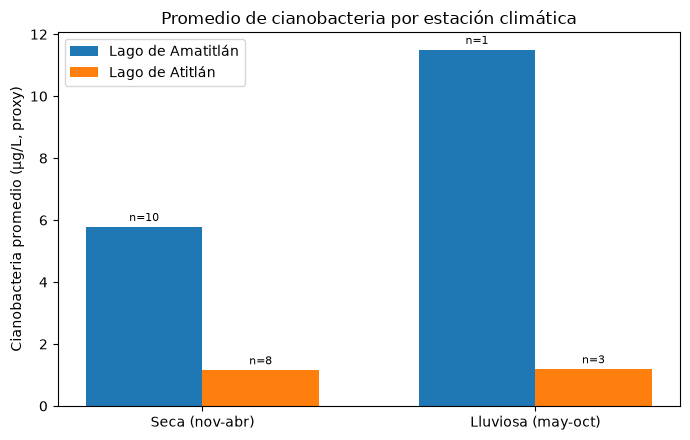

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
for i, lago in enumerate(sorted(LAGOS)):
    sub = df[df['lago'] == lago].set_index('estacion').reindex(['seca', 'lluviosa'])
    valores = sub['cyano_promedio'].values
    n = sub['n_fechas'].values
    barras = ax.bar(x + i * width, valores, width, label=LAGOS[lago].nombre)
    for xi, v, ni in zip(x + i * width, valores, n):
        if np.isfinite(v):
            ax.text(xi, v + 0.2, f'n={int(ni)}', ha='center', fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Seca (nov-abr)', 'Lluviosa (may-oct)'])
ax.set_ylabel('Cianobacteria promedio (µg/L, proxy)')
ax.set_title('Promedio de cianobacteria por estación climática')
ax.legend()
fig.tight_layout()
plt.show()


## Interpretación

**Amatitlán**: la única fecha de época lluviosa disponible (19 de junio de
2026) tiene el promedio más alto de toda la serie del lago, pero es una
sola observación (`n=1`) — no se puede afirmar con esto que la época
lluviosa cause valores más altos en Amatitlán; es igual de consistente con
que esa fecha específica coincidiera con el aumento reciente que ya se
observó en el ejercicio 4 (independientemente de la estación).

**Atitlán**: los promedios de época seca (n=8) y lluviosa (n=3) son
prácticamente iguales (1.14 vs. 1.18 µg/L). No hay indicio de un patrón
estacional en Atitlán durante el período observado.

## Limitación central

Las 11 fechas oficiales de cada lago cubren aproximadamente año y medio de
forma irregular, no un muestreo mensual sistemático. Varias combinaciones
lago-estación tienen muy pocas fechas (en particular, `n=1` para Amatitlán
en época lluviosa), así que estos resultados son indicios exploratorios,
no evidencia suficiente para afirmar una estacionalidad robusta. Cualquier
hipótesis climática debería contrastarse con registros meteorológicos
reales de la zona (por ejemplo, del INSIVUMEH) y con más fechas de las que
dispone este laboratorio.